In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
import csv

BASE = '../imc-prosperity-4-backtester/prosperity4bt/resources/round1'
DAYS = ['-2', '-1', '0']

price_rows = []
trade_rows = []
offset = 0

for day in DAYS:
    with open(f'{BASE}/prices_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)

    with open(f'{BASE}/trades_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)

    offset += 1_000_000

prices = pd.DataFrame(price_rows)
trades = pd.DataFrame(trade_rows)

for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')
trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['price']     = pd.to_numeric(trades['price'],     errors='coerce')
trades['quantity']  = pd.to_numeric(trades['quantity'],  errors='coerce')

print(prices['product'].unique())
print(f'prices rows: {len(prices)}  trades rows: {len(trades)}')

['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
prices rows: 59897  trades rows: 2276


In [ ]:
groups_prices = prices.groupby('product')
aco_prices = groups_prices.get_group('ASH_COATED_OSMIUM')

trades.drop(columns=[c for c in ['buyer','seller','currency'] if c in trades.columns], inplace=True)
groups_trades = trades.groupby('symbol')
aco_trades = groups_trades.get_group('ASH_COATED_OSMIUM')

In [25]:
def plot_prices(prices_df, title=None):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(prices_df.timestamp, prices_df['mid_price'], linewidth=1.2, color='steelblue')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.8, ls='--')
    for i, label in enumerate(['day -2', 'day -1', 'day 0']):
        ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
    ax.set_xlabel('Timestamp', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(title or 'Mid Price', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

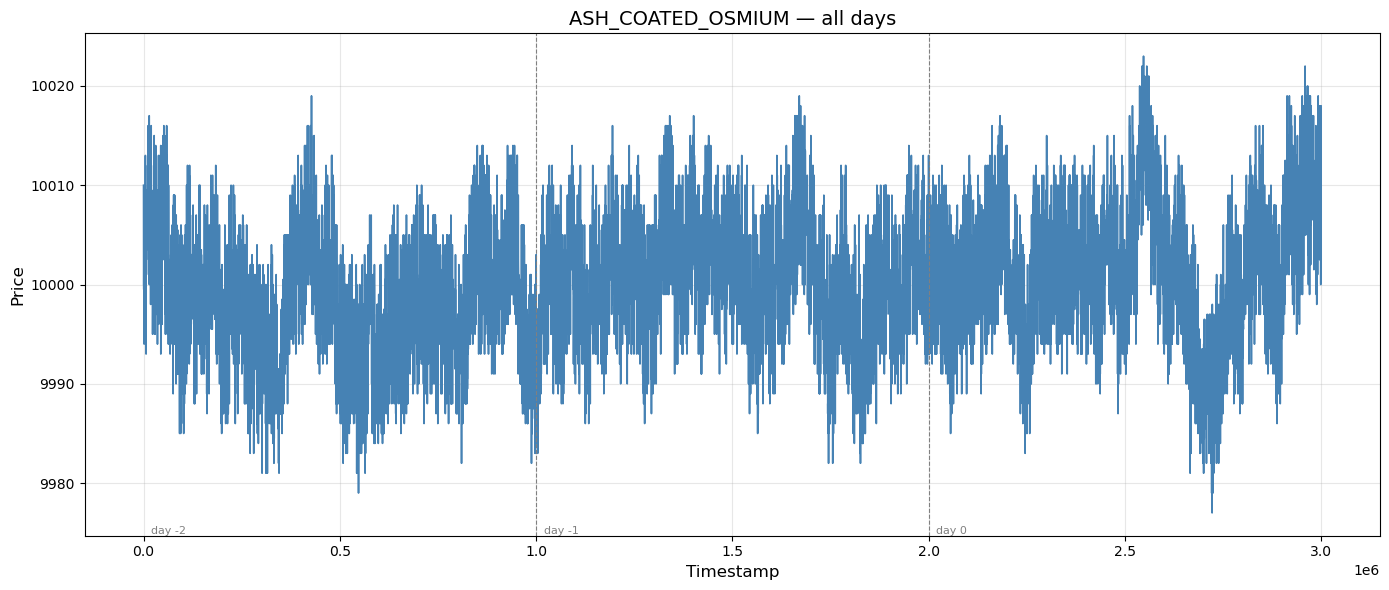

In [27]:
plot_prices(aco_prices, 'ASH_COATED_OSMIUM — all days')

In [28]:
def plot_trades(trades_df, title=None):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(14, 6))
    q_min, q_max = trades_df['quantity'].min(), trades_df['quantity'].max()
    sizes = 20 + (trades_df['quantity'] - q_min) / max(q_max - q_min, 1) * 280
    ax.scatter(trades_df.timestamp, trades_df['price'], s=sizes,
               color='red', alpha=0.4, edgecolors='darkred', linewidth=0.3,
               label='Trades (size ∝ quantity)')
    ax.set_xlabel('Timestamp', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(title or 'Trades', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

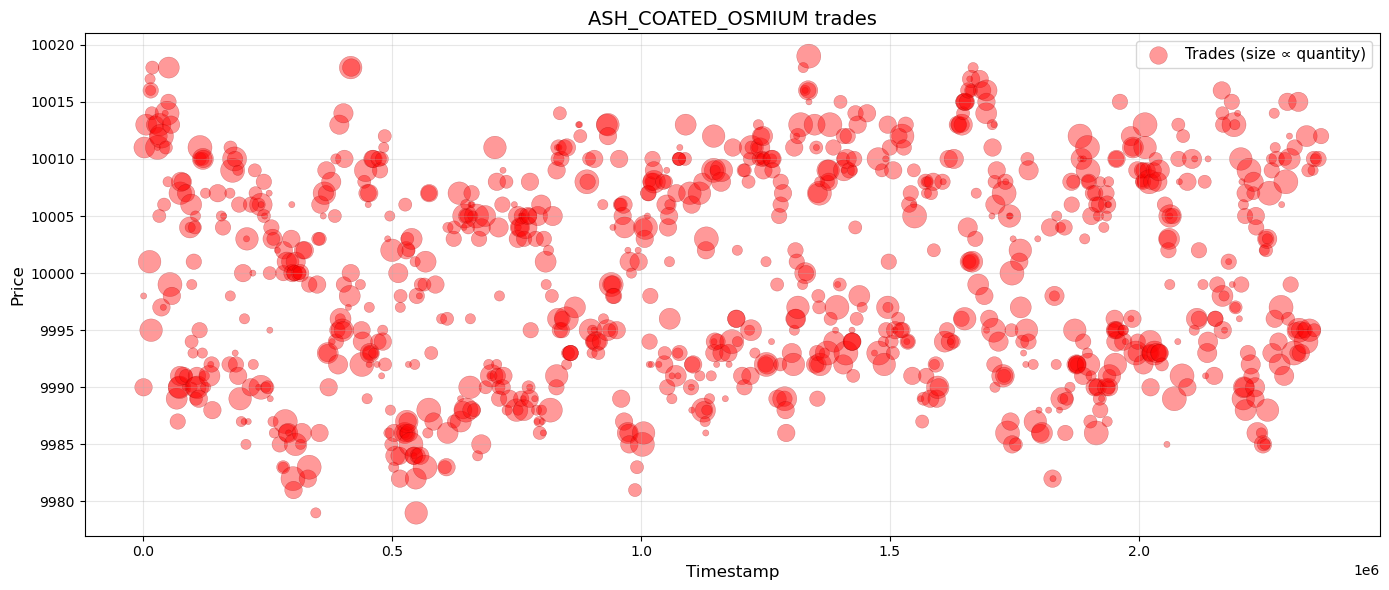

In [29]:
plot_trades(aco_trades[:1_000], 'ASH_COATED_OSMIUM trades')

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

def run_time_series_suite(series, change_point=False):
    results = {}
    clean = series.dropna()

    print('Running ADF test...')
    adf = adfuller(clean)
    results['ADF (Stationarity)'] = {'p-value': adf[1], 'Stationary': adf[1] < 0.05}

    print('Running KPSS test...')
    kpss_res = kpss(clean, regression='c', nlags='auto')
    results['KPSS (Trend Stationary)'] = {'p-value': kpss_res[1], 'Stationary': kpss_res[1] > 0.05}

    print('Running Ljung-Box test...')
    lb = acorr_ljungbox(clean, lags=[10], return_df=True)
    results['Ljung-Box (White Noise)'] = {'p-value': lb['lb_pvalue'].values[0], 'Is White Noise': lb['lb_pvalue'].values[0] > 0.05}

    if change_point:
        import ruptures as rpt
        print('Running Change-point Analysis...')
        algo = rpt.Pelt(model='rbf').fit(clean.values)
        cps = algo.predict(pen=10)
        results['Change Points Detected'] = len(cps) - 1

    print('Done!')
    results['Descriptive'] = {
        'Mean': clean.mean(), 'Std Dev': clean.std(),
        'Skewness': clean.skew(), 'Kurtosis': clean.kurt()
    }
    return results

In [31]:
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
import scipy.stats as stats

def run_advanced_series_suite(series):
    results = {}
    clean = series.dropna()

    H, c, data = compute_Hc(clean, kind='price', simplified=True)
    results['Hurst Exponent'] = {
        'Value': H,
        'Interpretation': 'Mean-Reverting' if H < 0.45 else 'Trending' if H > 0.55 else 'Martingale/Random Walk'
    }

    vr = VarianceRatio(clean)
    results['Variance Ratio (Martingale)'] = {'p-value': vr.pvalue, 'Is Random Walk': vr.pvalue > 0.05}

    kurt = stats.kurtosis(clean)
    results['Volatility Profile'] = {
        'Excess Kurtosis': kurt, 'Has Fat Tails': kurt > 1, 'Std Dev': clean.std()
    }
    return results

In [32]:
print('=== ACO ===')
run_time_series_suite(aco_prices['mid_price'])

=== ACO ===
Running ADF test...
Running KPSS test...
Running Ljung-Box test...
Done!


/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_7548/3506290995.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(clean, regression='c', nlags='auto')


{'ADF (Stationarity)': {'p-value': np.float64(4.2783808508349425e-07),
  'Stationary': np.True_},
 'KPSS (Trend Stationary)': {'p-value': np.float64(0.01),
  'Stationary': np.False_},
 'Ljung-Box (White Noise)': {'p-value': np.float64(0.0),
  'Is White Noise': np.False_},
 'Descriptive': {'Mean': np.float64(10000.204233581517),
  'Std Dev': 5.349695209772018,
  'Skewness': np.float64(-0.04508905939207592),
  'Kurtosis': np.float64(0.30329180215883644)}}

In [33]:
print('=== ACO advanced ===')
run_advanced_series_suite(aco_prices['mid_price'])

=== ACO advanced ===


{'Hurst Exponent': {'Value': np.float64(0.18278983542592042),
  'Interpretation': 'Mean-Reverting'},
 'Variance Ratio (Martingale)': {'p-value': np.float64(0.0),
  'Is Random Walk': np.False_},
 'Volatility Profile': {'Excess Kurtosis': np.float64(0.30304085268108594),
  'Has Fat Tails': np.False_,
  'Std Dev': 5.349695209772018}}

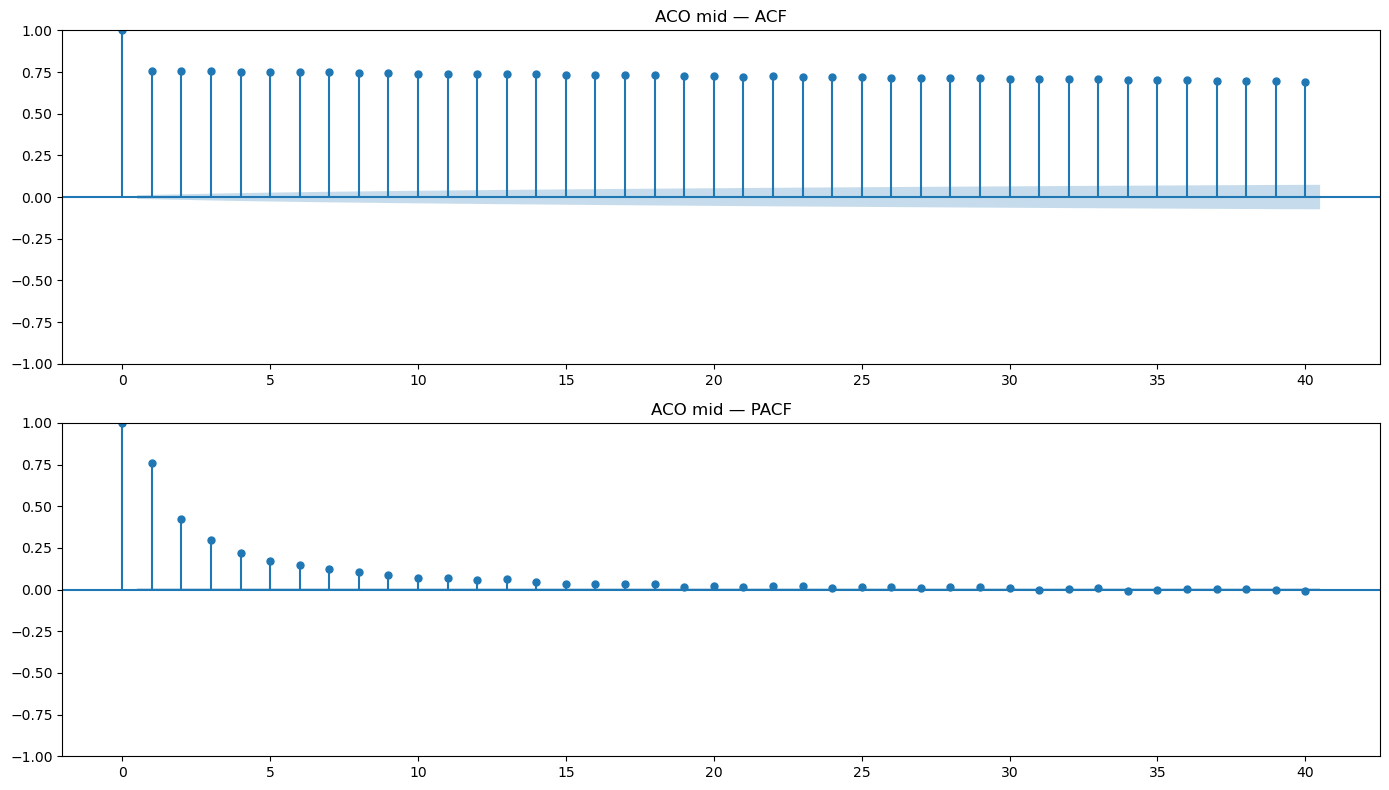

In [38]:
# ACF / PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(aco_prices['mid_price'].dropna(),  lags=40, ax=axes[0], title='ACO mid — ACF')
plot_pacf(aco_prices['mid_price'].dropna(), lags=40, ax=axes[1], title='ACO mid — PACF')

plt.tight_layout()
plt.show()

## ASH_COATED_OSMIUM — Time Series Summary

| Test | Result | Interpretation |
|------|--------|----------------|
| **ADF** (stationarity) | p = 4.3e-7 ✓ | Price series is **stationary** |
| **KPSS** (trend-stationarity) | p = 0.01 ✗ | NOT trend-stationary (contradicts ADF — likely oscillates around a drifting mean) |
| **Ljung-Box** (white noise) | p ≈ 0 ✗ | **Not white noise** — significant autocorrelation structure present |
| **Hurst Exponent** | H = 0.183 | Strongly **mean-reverting** (H << 0.5) |
| **Variance Ratio** | p ≈ 0 ✗ | **Not a random walk** — predictable structure exists |
| **Kurtosis** | 0.30 | Thin tails, near-Gaussian returns |
| **Mean / Std** | μ ≈ 10000.2, σ ≈ 5.35 | Tight oscillation around a ~10000 fair value |

**Takeaway:** ACO is a strong mean-reversion candidate. Low Hurst, stationary price, and strong autocorrelation all point to a market-making / pairs-style strategy. The fair value is stable near 10000.

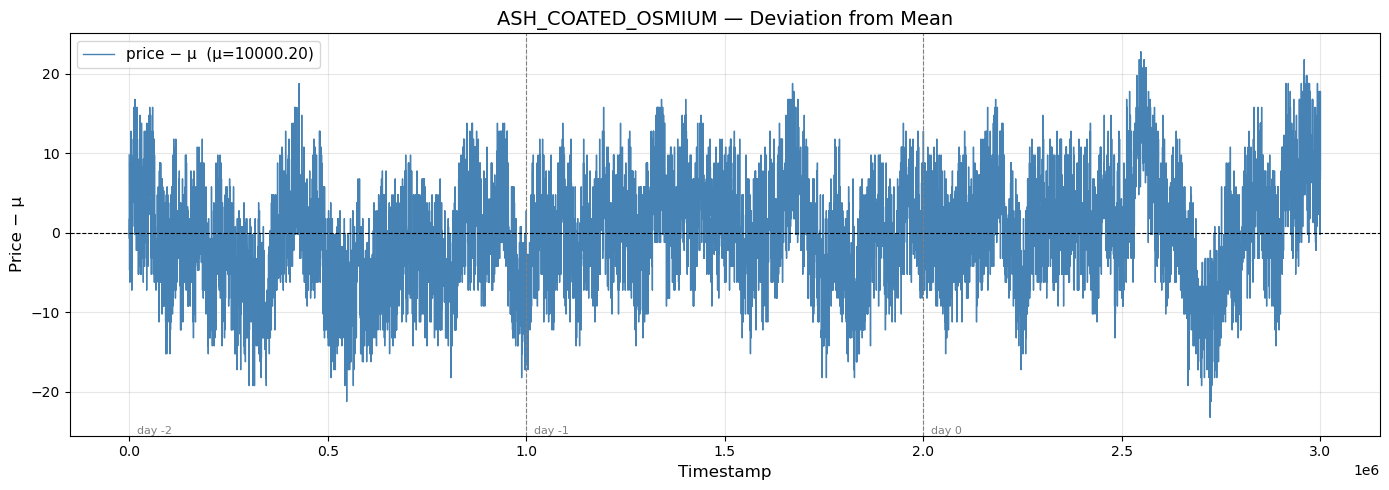

In [39]:
mu = aco_prices['mid_price'].mean()
deviation = aco_prices['mid_price'] - mu

plt.close('all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aco_prices['timestamp'], deviation, linewidth=1.0, color='steelblue', label=f'price − μ  (μ={mu:.2f})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Price − μ', fontsize=12)
ax.set_title('ASH_COATED_OSMIUM — Deviation from Mean', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

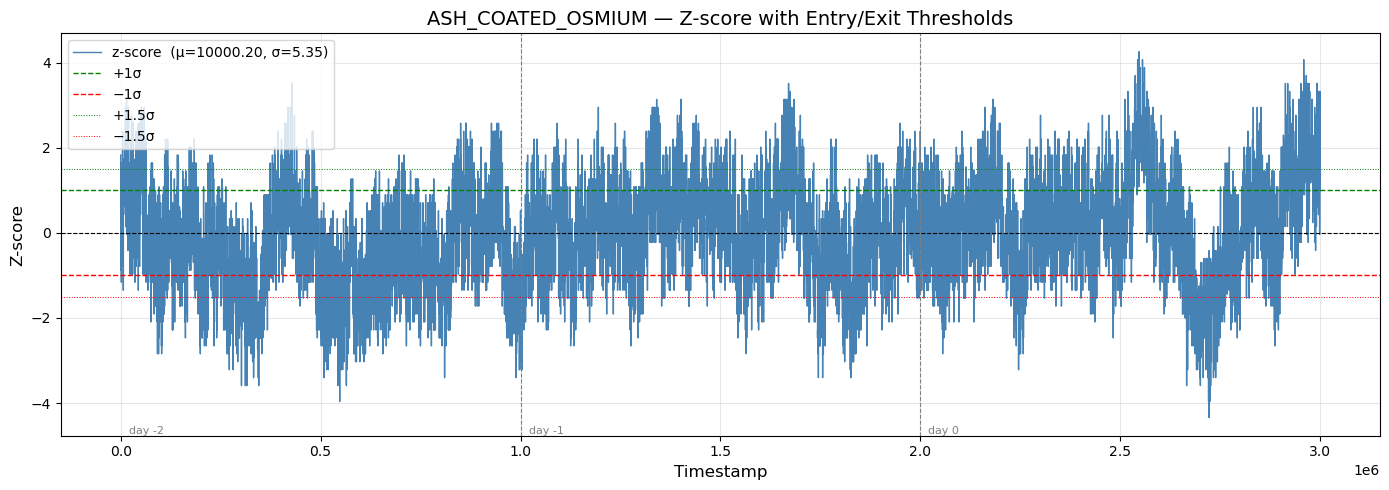

μ=10000.2042  σ=5.3497
% of time |z| > 1.0: 29.0%
% of time |z| > 1.5: 13.7%


In [41]:
mu    = aco_prices['mid_price'].mean()
sigma = aco_prices['mid_price'].std()
z     = (aco_prices['mid_price'] - mu) / sigma

plt.close('all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aco_prices['timestamp'], z, linewidth=1.0, color='steelblue', label=f'z-score  (μ={mu:.2f}, σ={sigma:.2f})')
ax.axhline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axhline( 1.0, color='green',  linewidth=1.0, linestyle='--', label='+1σ')
ax.axhline(-1.0, color='red',    linewidth=1.0, linestyle='--', label='−1σ')
ax.axhline( 1.5, color='green',  linewidth=0.7, linestyle=':',  label='+1.5σ')
ax.axhline(-1.5, color='red',    linewidth=0.7, linestyle=':',  label='−1.5σ')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -2', 'day -1', 'day 0']):
    ax.text(i * 1_000_000 + 20_000, ax.get_ylim()[0], label, fontsize=8, color='gray', va='bottom')
ax.set_xlabel('Timestamp', fontsize=12)
ax.set_ylabel('Z-score', fontsize=12)
ax.set_title('ASH_COATED_OSMIUM — Z-score with Entry/Exit Thresholds', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'μ={mu:.4f}  σ={sigma:.4f}')
print(f'% of time |z| > 1.0: {(z.abs() > 1.0).mean()*100:.1f}%')
print(f'% of time |z| > 1.5: {(z.abs() > 1.5).mean()*100:.1f}%')